# 🧠 Tripolar EEG — Single Subject Analysis

Run this notebook to analyze **one subject** at a time. It loads the raw BrainVision files, performs full spectral decomposition, and generates all per-channel figures.

For group-level analysis across all subjects, see `group_analysis.ipynb`.

In [1]:
import sys
import os
sys.path.insert(0, '.')
from eeg_analysis import *

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Auto-save figures to Figures/ when displayed
FIGURES_DIR = 'Figures'
_save_counter = [0]
_original_show = plt.show
def _show_and_save():
    fig = plt.gcf()
    subdir = FIGURES_DIR
    if 'SUBJECT' in globals():
        subdir = os.path.join(FIGURES_DIR, str(SUBJECT))
    os.makedirs(subdir, exist_ok=True)
    _save_counter[0] += 1
    fname = os.path.join(subdir, f'fig_{_save_counter[0]:03d}.png')
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    _original_show()
plt.show = _show_and_save

print("Ready ✓ (figures auto-save to Figures/)")

Ready ✓ (figures auto-save to Figures/)


## 1. Discover Available Subjects

In [2]:
DATA_DIR = '/home/tnlab_sk/Desktop/Tripolar_EEG/data'

subjects = discover_subjects(DATA_DIR)
print(f"Found {len(subjects)} subjects:\n")
for s in subjects:
    avg_status = "✓" if s['avg'] else "✗"
    vmrk_status = "✓" if s['vmrk'] else "✗"
    print(f"  {s['name']:<15s}  files: {s['basename']}")
    print(f"  {'':15s}  markers: {vmrk_status}   avg: {avg_status}")
    print()

Found 9 subjects:

  CP1              files: CP1 2-22-26
                   markers: ✓   avg: ✓

  Caitlin 1        files: Caitlin 1 2-11-26
                   markers: ✓   avg: ✓

  Gab              files: Gab
                   markers: ✓   avg: ✓

  Hunter1          files: Hunter1 217-26
                   markers: ✓   avg: ✓

  LS1              files: LS1 2-11-26
                   markers: ✓   avg: ✓

  LSF1             files: LSF1 2-11-26
                   markers: ✓   avg: ✓

  LuciTest         files: LuciTest
                   markers: ✓   avg: ✓

  SK1              files: SK1 2-19-2026
                   markers: ✓   avg: ✓

  TU               files: TU 12-10-2026
                   markers: ✓   avg: ✓



## 2. Load a Subject

Change the `SUBJECT` variable below to analyze a different subject.

In [3]:
# ═══════════════════════════════════════
# CHANGE THIS to select your subject
# ═══════════════════════════════════════
SUBJECT = 'CP1 '# or use a specific name like 'SK1'

print(f"Loading: {SUBJECT}")
subject = load_subject(DATA_DIR, SUBJECT)
print(f"  EEG shape:     {subject['eeg'].shape}")
print(f"  Duration:      {subject['n_samples']/FS:.1f}s ({subject['n_samples']/FS/60:.1f} min)")
print(f"  Stim triggers: {len(subject['stim_samples'])}")
print(f"  Stim blocks:   {len(subject['stim_blocks'])}")
print(f"  Open/close:    {len(subject['events_oc'])} markers → {len(subject['epochs_oc'])} epochs")
print(f"  Averaged VEP:  {'Yes (n=' + str(subject['avg_n_segments']) + ')' if subject['avg_data'] is not None else 'Not available'}")

if subject['epochs_oc']:
    print(f"\nEpochs:")
    for ep in subject['epochs_oc']:
        print(f"  {ep['label']:>5s}: {ep['start_s']:6.1f}s – {ep['end_s']:6.1f}s  ({ep['dur']:.1f}s)")

Loading: CP1 
  EEG shape:     (11, 542540)
  Duration:      542.5s (9.0 min)
  Stim triggers: 40
  Stim blocks:   2
  Open/close:    11 markers → 11 epochs
  Averaged VEP:  Yes (n=64)

Epochs:
   open:  104.1s –  153.0s  (48.9s)
  close:  153.0s –  182.9s  (29.9s)
   open:  182.9s –  214.3s  (31.4s)
  close:  214.3s –  242.9s  (28.6s)
   open:  242.9s –  272.6s  (29.7s)
  close:  272.6s –  303.5s  (30.8s)
   open:  303.5s –  422.9s  (119.5s)
  close:  422.9s –  453.3s  (30.4s)
   open:  453.3s –  482.5s  (29.2s)
  close:  482.5s –  513.1s  (30.6s)
   open:  513.1s –  542.5s  (29.4s)


## 3. Channel Statistics

In [4]:
eeg = subject['eeg']
print(f"{'Channel':<30} {'Min(µV)':>9} {'Max(µV)':>9} {'Std(µV)':>9} {'Clipping?':>10}")
print("═" * 72)
for i in range(N_CHANNELS):
    clips = "⚠ YES" if eeg[i].max() >= 3276.6 or eeg[i].min() <= -3276.6 else ""
    print(f"{CH_LABELS[i]:<30} {eeg[i].min():>9.1f} {eeg[i].max():>9.1f} "
          f"{eeg[i].std():>9.1f} {clips:>10}")

Channel                          Min(µV)   Max(µV)   Std(µV)  Clipping?
════════════════════════════════════════════════════════════════════════
Ch1 – Felt TCRE #1 (tEEG)        -3276.7    3276.7     909.9      ⚠ YES
Ch2 – Felt TCRE #1 (eEEG)        -3276.7    3276.7     153.0      ⚠ YES
Ch3 – Felt TCRE #2 (tEEG)        -3276.7    3276.7    1239.1      ⚠ YES
Ch4 – Felt TCRE #2 (eEEG)        -3276.7    3276.7     159.9      ⚠ YES
Ch5 – Felt TCRE #3 (tEEG)        -3276.7    3276.7     854.6      ⚠ YES
Ch6 – Felt TCRE #3 (eEEG)        -2217.5    1733.3      41.6           
Ch7 – Felt TCRE #4 (tEEG)        -3276.7    3276.7     732.9      ⚠ YES
Ch8 – Felt TCRE #4 (eEEG)        -3276.7    1949.3      95.7      ⚠ YES
Ch9 – Paste TCRE #5 (tEEG)       -3276.7    3276.7     308.6      ⚠ YES
Ch10 – Paste TCRE #5 (eEEG)       -766.7     871.3      51.8           
Ch11 – Paste Disc (eEEG)         -2871.7     811.7     258.6           


## 4. Run Analysis

In [5]:
results = analyze_subject(subject)
print("Analysis complete ✓")
print(f"\n{'Channel':<30} {'αSNR(dB)':>9} {'αReact':>8} {'CorrDisc':>9} {'VEP P2P':>9}")
print("═" * 70)
for i in range(N_CHANNELS):
    print(f"{CH_LABELS[i]:<30} {results['alpha_snr'][i]:>8.2f}  "
          f"{results['alpha_reactivity'][i]:>7.2f}x {results['disc_correlation'][i]:>8.4f}  "
          f"{results['vep_p2p'][i]:>8.1f}")

Analysis complete ✓

Channel                         αSNR(dB)   αReact  CorrDisc   VEP P2P
══════════════════════════════════════════════════════════════════════
Ch1 – Felt TCRE #1 (tEEG)          1.90     1.47x   0.4136     156.4
Ch2 – Felt TCRE #1 (eEEG)          0.21     0.22x   0.1244       2.7
Ch3 – Felt TCRE #2 (tEEG)          0.87     1.11x   0.2409     147.9
Ch4 – Felt TCRE #2 (eEEG)          0.52     0.03x   0.0851       9.5
Ch5 – Felt TCRE #3 (tEEG)         -0.43     0.44x   0.2212     181.4
Ch6 – Felt TCRE #3 (eEEG)          0.63     0.08x  -0.0481       0.5
Ch7 – Felt TCRE #4 (tEEG)          1.39     1.11x  -0.0303     176.5
Ch8 – Felt TCRE #4 (eEEG)          2.25     0.42x  -0.0193      14.6
Ch9 – Paste TCRE #5 (tEEG)         2.48     1.27x   0.9856      80.5
Ch10 – Paste TCRE #5 (eEEG)       -0.37     1.01x   0.8815       9.4
Ch11 – Paste Disc (eEEG)          -0.47     1.25x   1.0000       9.5


## 5. Summary Dashboard

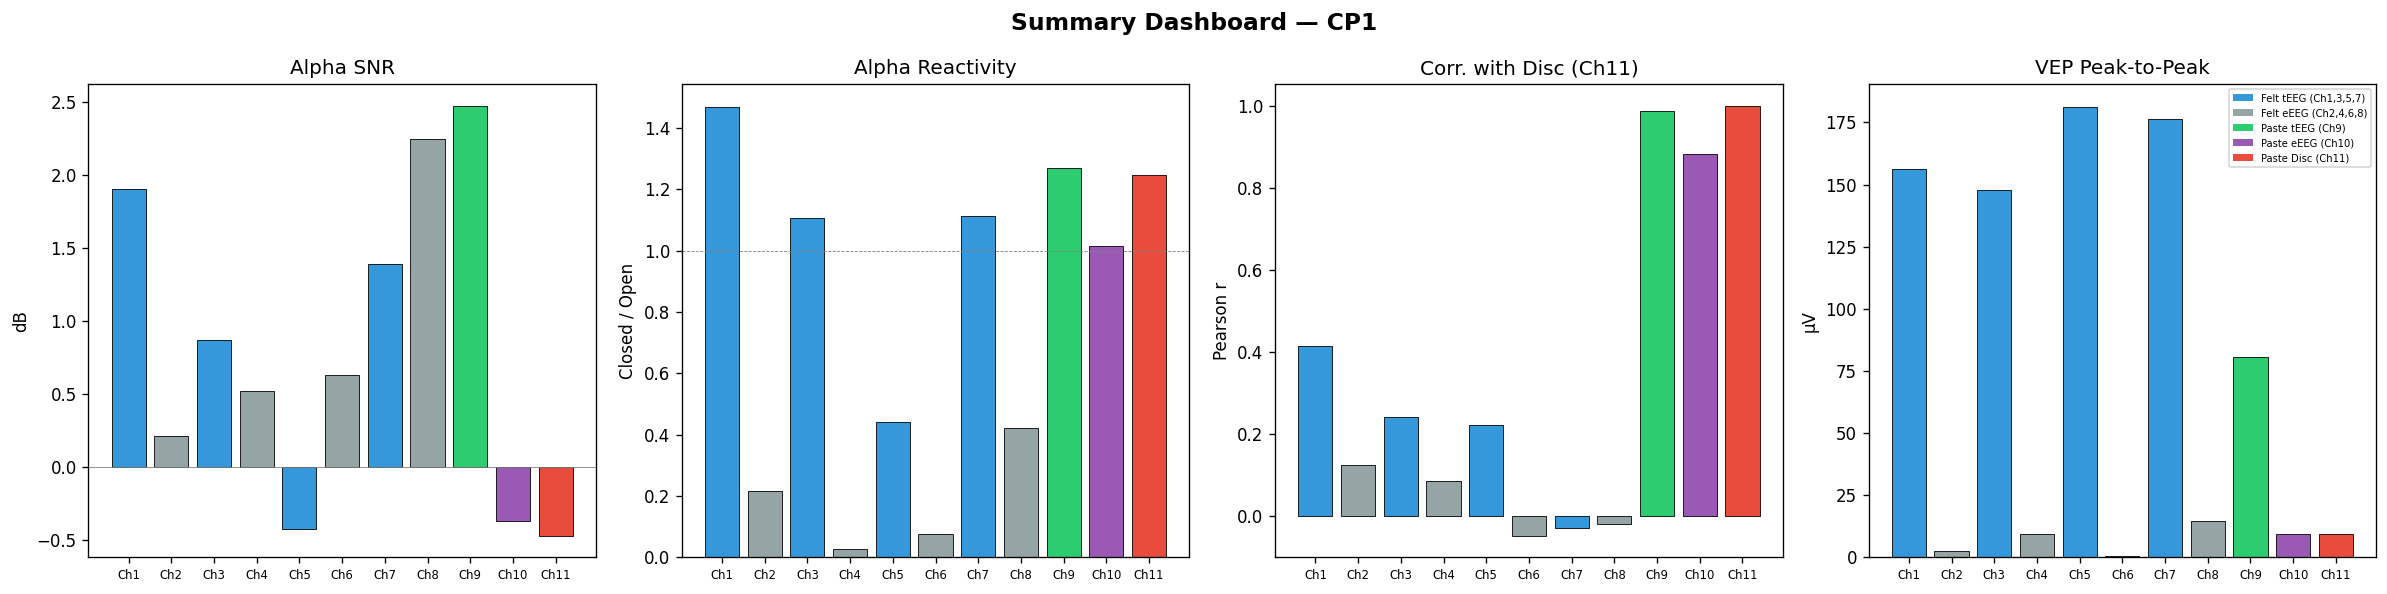

In [6]:
plot_subject_summary(subject, results)

## 6. Raw Time Series with Events

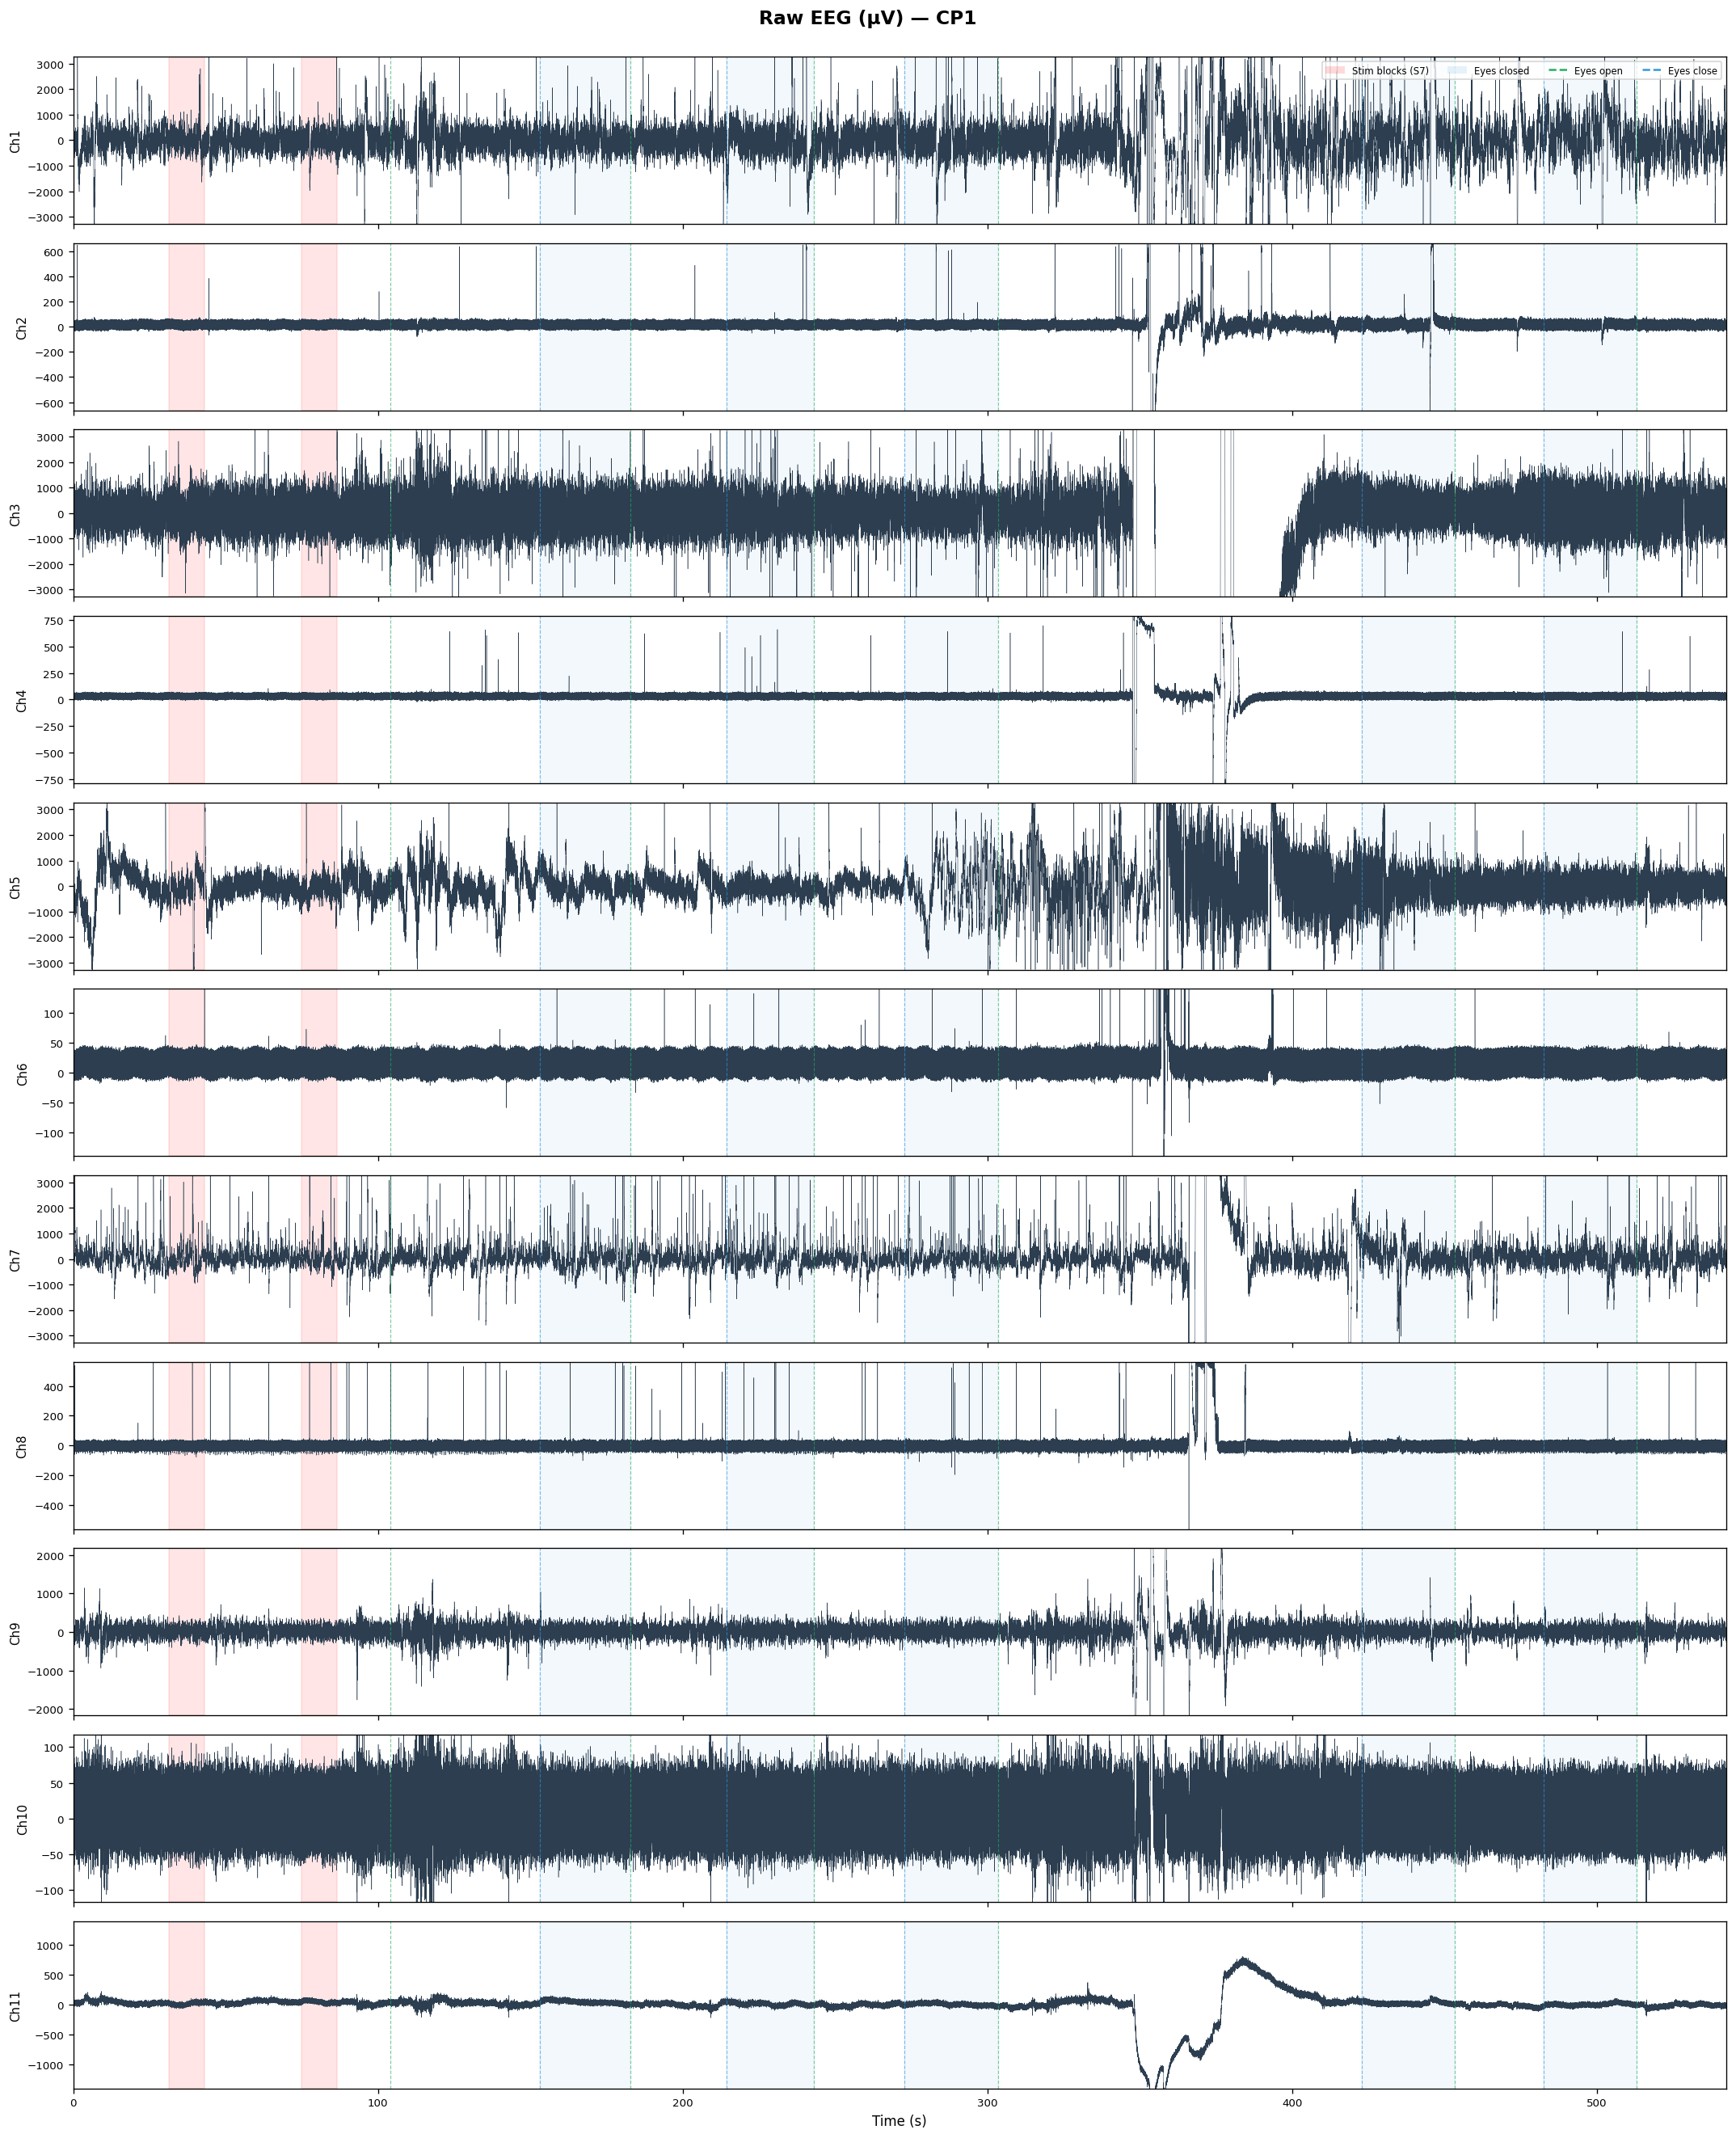

In [7]:
fig, axes = plt.subplots(11, 1, figsize=(18, 22), sharex=True)
fig.suptitle(f'Raw EEG (µV) — {subject["name"]}', fontsize=14, fontweight='bold', y=1.0)
ds = 10
for i in range(N_CHANNELS):
    ax = axes[i]
    ax.plot(subject['t'][::ds], eeg[i, ::ds], lw=0.3, color='#2c3e50')
    ax.set_ylabel(f'Ch{i+1}', fontsize=9)
    ymax = np.percentile(np.abs(eeg[i]), 99.5)
    ax.set_ylim(-ymax, ymax); ax.tick_params(labelsize=8)
    add_event_markers(ax, subject['events_oc'], subject['stim_blocks'], subject['close_epochs'])
axes[0].legend(handles=EVENT_LEGEND, fontsize=7, loc='upper right', ncol=4)
axes[0].set_xlim(0, subject['t'][-1])
axes[-1].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()

## 7. PSD — Alpha Focus (1–30 Hz, 60 Hz notch)

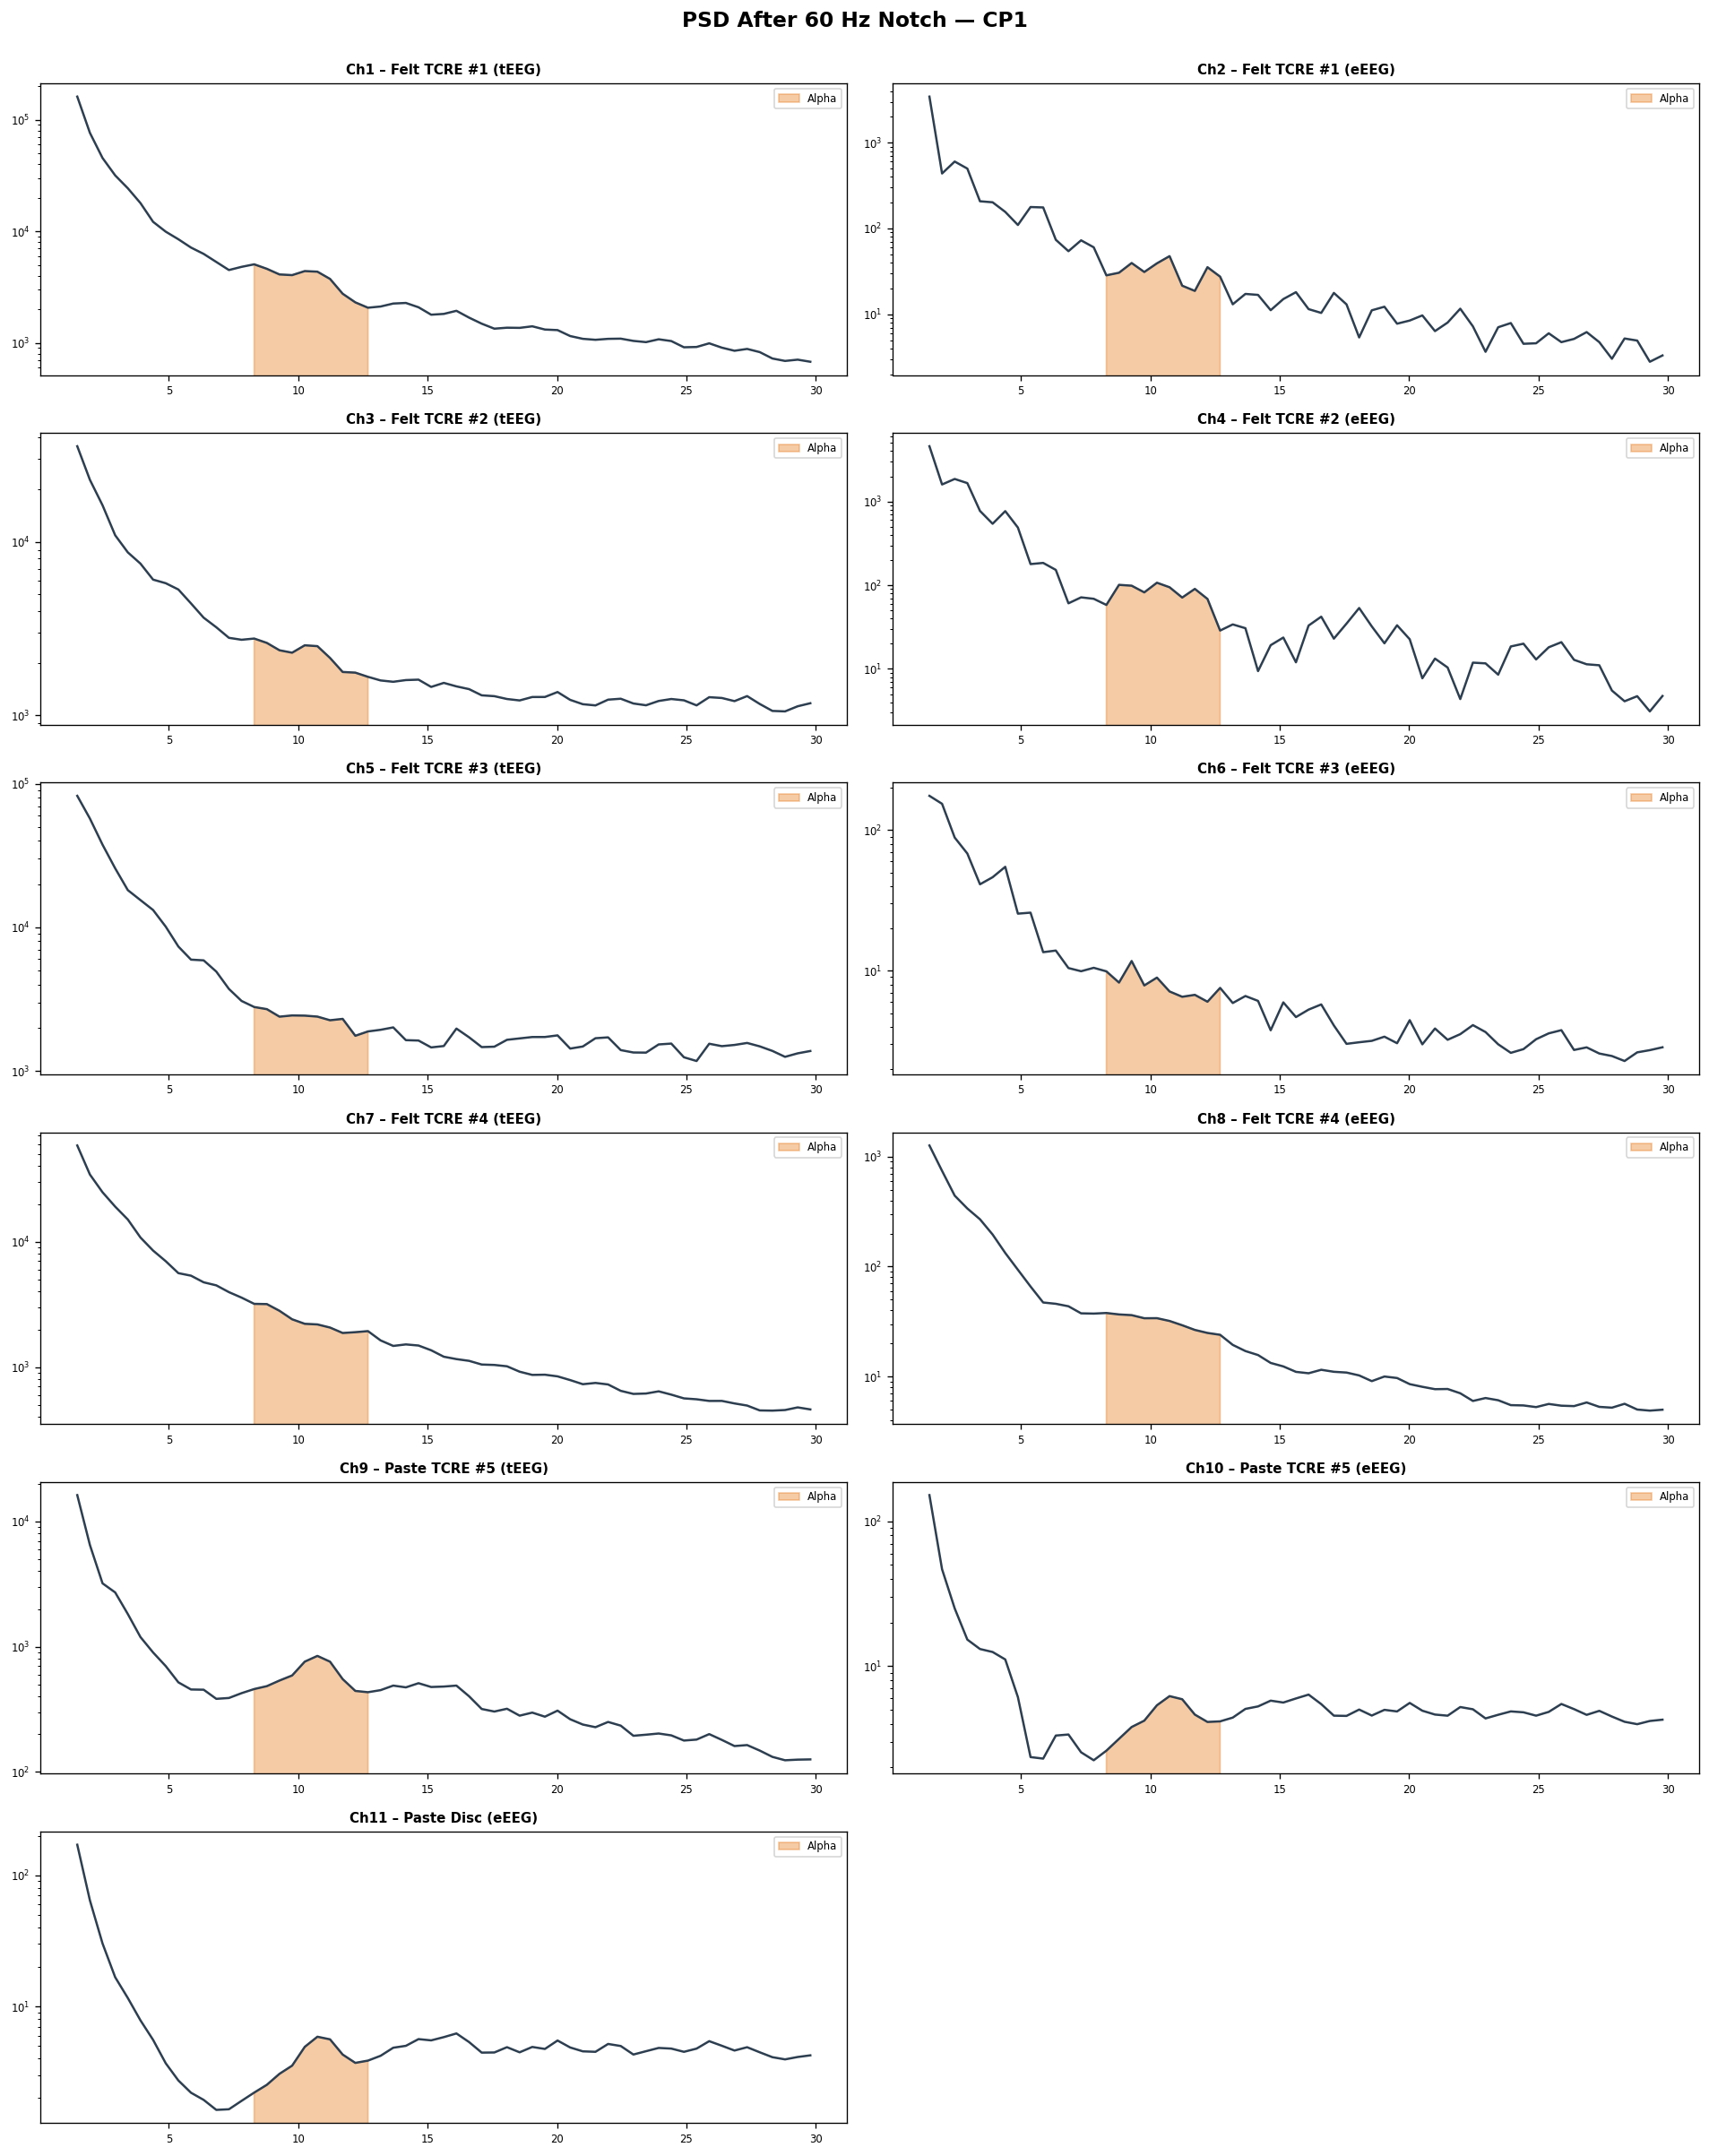

In [8]:
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
fig.suptitle(f'PSD After 60 Hz Notch — {subject["name"]}', fontsize=14, fontweight='bold', y=1.0)
for i in range(N_CHANNELS):
    ax = axes.flatten()[i]
    cleaned = notch_filter(eeg[i])
    f, pxx = signal.welch(cleaned, fs=FS, nperseg=2048)
    mask = (f >= 1) & (f <= 30)
    ax.semilogy(f[mask], pxx[mask], lw=1.5, color='#2c3e50')
    amask = (f >= 8) & (f <= 13) & mask
    ax.fill_between(f[amask], pxx[amask], alpha=0.4, color='#e67e22', label='Alpha')
    ax.set_title(CH_LABELS[i], fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)
axes.flatten()[11].set_visible(False)
plt.tight_layout(); plt.show()

In [10]:
import numpy as np
from specparam import SpectralModel

sm = SpectralModel(peak_width_limits=[1, 8], max_n_peaks=6, aperiodic_mode='fixed')
alpha_results = []
all_pxx = np.zeros((N_CHANNELS, 1025))

fig, axes = plt.subplots(6, 2, figsize=(16, 20))
fig.suptitle(f'PSD After 60 Hz Notch — {subject["name"]}', fontsize=14, fontweight='bold', y=1.0)

for i in range(N_CHANNELS):
    ax = axes.flatten()[i]
    cleaned = notch_filter(eeg[i])
    f, pxx = signal.welch(cleaned, fs=FS, nperseg=2048)
    all_pxx[i] = pxx

    # Plot
    mask = (f >= 1) & (f <= 30)
    ax.semilogy(f[mask], pxx[mask], lw=1.5, color='#2c3e50')
    amask = (f >= 8) & (f <= 13) & mask
    ax.fill_between(f[amask], pxx[amask], alpha=0.4, color='#e67e22', label='Alpha')

    # Spectral parameterization
    sm.fit(f, pxx, [1, 30])
    peaks = sm.get_params('peak')
    aperiodic = sm.get_params('aperiodic')
    r_squared = float(np.squeeze(sm.get_metrics('gof', 'rsquared')))


    # Quality check
    reliable = True
    if aperiodic[1] < 0.3:
        reliable = False

    # Alpha extraction
    if len(peaks) > 0:
        alpha_mask_p = (peaks[:, 0] >= 8) & (peaks[:, 0] <= 13)
        alpha_peaks = peaks[alpha_mask_p]
    else:
        alpha_peaks = []

    if len(alpha_peaks) > 0:
        best = alpha_peaks[np.argmax(alpha_peaks[:, 1])]
        alpha_results.append({
            'channel': CH_LABELS[i],
            'alpha_freq': best[0],
            'alpha_amp': best[1],
            'offset': aperiodic[0],
            'exponent': aperiodic[1],
            'r_squared': r_squared,
            'reliable': reliable
        })
        ax.axvline(best[0], color='red', ls='--', alpha=0.5, label=f'α={best[0]:.1f} Hz')
    else:
        alpha_results.append({
            'channel': CH_LABELS[i],
            'alpha_freq': None,
            'alpha_amp': 0,
            'offset': aperiodic[0],
            'exponent': aperiodic[1],
            'r_squared': r_squared,
            'reliable': reliable
        })

    ax.set_title(CH_LABELS[i], fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

axes.flatten()[11].set_visible(False)
plt.tight_layout()
plt.show()

# Summary
print(f"\n{'Channel':<35} {'Alpha':<30} {'Aperiodic':<30} {'R²':<8} {'Quality'}")
print("=" * 110)
for r in alpha_results:
    if r['alpha_freq']:
        alpha_str = f"α = {r['alpha_freq']:.2f} Hz, amp = {r['alpha_amp']:.2f}"
    else:
        alpha_str = "No alpha"
    aperiodic_str = f"offset={r['offset']:.2f}, slope={r['exponent']:.2f}"
    quality = "✅" if r['reliable'] else "⚠️ poor aperiodic fit"
    print(f"{r['channel']:<35} {alpha_str:<30} {aperiodic_str:<30} {r['r_squared']:.2f}    {quality}")

ModuleNotFoundError: No module named 'specparam'

## 8. Spectrograms — Per Channel

In [ ]:
for i in range(N_CHANNELS):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), gridspec_kw={'height_ratios': [1, 3]})
    fig.suptitle(f'Spectrogram — {subject["name"]} — {CH_LABELS[i]}', fontsize=12, fontweight='bold')
    cleaned = notch_filter(eeg[i])
    bp = bandpass_filter(cleaned, 1, 45)
    ax1.plot(subject['t'][::10], bp[::10], lw=0.3, color='#34495e')
    ax1.set_ylabel('µV'); ax1.set_xlim(0, subject['t'][-1])
    add_event_markers(ax1, subject['events_oc'], subject['stim_blocks'], subject['close_epochs'], text_labels=True)
    nperseg = 2048
    f_s, t_s, Sxx = signal.spectrogram(cleaned, fs=FS, nperseg=nperseg, noverlap=nperseg//2, nfft=2048)
    fm = f_s <= 45
    im = ax2.pcolormesh(t_s, f_s[fm], 10*np.log10(Sxx[fm]+1e-10), shading='gouraud', cmap='inferno', vmin=-20)
    ax2.set_ylabel('Hz'); ax2.set_xlabel('Time (s)'); ax2.set_ylim(1, 45)
    ax2.axhline(8, color='cyan', lw=0.8, ls='--', alpha=0.7)
    ax2.axhline(13, color='cyan', lw=0.8, ls='--', alpha=0.7)
    add_event_markers(ax2, subject['events_oc'], subject['stim_blocks'], subject['close_epochs'], shade_close=False, text_labels=True)
    plt.colorbar(im, ax=ax2, label='dB')
    plt.tight_layout(); plt.show(); print()

## 9. Band Decomposition — Per Channel

In [ ]:
for i in range(N_CHANNELS):
    fig, axs = plt.subplots(len(BANDS)+1, 1, figsize=(16, 10), sharex=True,
                             gridspec_kw={'height_ratios': [2]+[1]*len(BANDS)})
    fig.suptitle(f'Band Decomposition — {subject["name"]} — {CH_LABELS[i]}', fontsize=12, fontweight='bold')
    cleaned = notch_filter(eeg[i])
    ds = 20
    bp_full = bandpass_filter(cleaned, 1, 45)
    axs[0].plot(subject['t'][::ds], bp_full[::ds], lw=0.3, color='#2c3e50')
    axs[0].set_title('Broadband (1–45 Hz)', fontsize=10); axs[0].set_ylabel('µV', fontsize=8)
    for j, (bname, (lo, hi)) in enumerate(BANDS.items()):
        ax = axs[j+1]
        bp = bandpass_filter(cleaned, lo, hi)
        ax.plot(subject['t'][::ds], bp[::ds], lw=0.4, color=BAND_COLORS[bname])
        ax.set_title(f'{bname} ({lo}–{hi} Hz)', fontsize=10, color=BAND_COLORS[bname])
        ax.set_ylabel('µV', fontsize=8)
    for ax in axs:
        ax.set_xlim(0, subject['t'][-1]); ax.tick_params(labelsize=7)
        add_event_markers(ax, subject['events_oc'], subject['stim_blocks'], subject['close_epochs'])
    axs[-1].set_xlabel('Time (s)')
    plt.tight_layout(); plt.show(); print()

## 10. Alpha Envelope with Events

In [ ]:
fig, axes = plt.subplots(11, 1, figsize=(17, 24), sharex=True)
fig.suptitle(f'Alpha Envelope (8–13 Hz) — {subject["name"]}', fontsize=14, fontweight='bold', y=1.0)
ds = 50
for i in range(N_CHANNELS):
    ax = axes[i]; env = results['alpha_envelopes'][i]
    ax.plot(subject['t'][::ds], env[::ds], lw=1, color='#e74c3c')
    ax.fill_between(subject['t'][::ds], 0, env[::ds], alpha=0.2, color='#e74c3c')
    ax.set_ylabel(f'Ch{i+1}', fontsize=9); ax.tick_params(labelsize=8)
    add_event_markers(ax, subject['events_oc'], subject['stim_blocks'], subject['close_epochs'])
axes[0].legend(handles=EVENT_LEGEND, fontsize=7, loc='upper right', ncol=4)
axes[0].set_xlim(0, subject['t'][-1])
axes[-1].set_xlabel('Time (s)'); plt.tight_layout(); plt.show()

## 11. Eyes Open vs Closed

In [ ]:
if subject['open_epochs'] and subject['close_epochs']:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Alpha Reactivity — {subject["name"]}', fontsize=13, fontweight='bold')
    x = np.arange(N_CHANNELS); w = 0.35
    ax1.bar(x-w/2, results['alpha_open'], w, color='#27ae60', label='Open', edgecolor='k', lw=0.5)
    ax1.bar(x+w/2, results['alpha_closed'], w, color='#3498db', label='Closed', edgecolor='k', lw=0.5)
    ax1.set_xticks(x); ax1.set_xticklabels(SHORT_LABELS, fontsize=9)
    ax1.set_ylabel('Alpha Power (µV²/Hz)'); ax1.set_title('Absolute'); ax1.legend(); ax1.set_yscale('log')
    ax2.bar(x, results['alpha_reactivity'], color=[ch_color(i) for i in range(N_CHANNELS)], edgecolor='k', lw=0.5)
    ax2.axhline(1, color='gray', lw=1, ls='--')
    ax2.set_xticks(x); ax2.set_xticklabels(SHORT_LABELS, fontsize=9)
    ax2.set_ylabel('Closed / Open'); ax2.set_title('Reactivity (>1 = Berger effect)')
    ax2.legend(handles=ELEC_LEGEND, fontsize=7, loc='upper right')
    plt.tight_layout(); plt.show()
else:
    print("No eyes open/close markers found for this subject.")

## 11b. Eyes Open vs Closed — Per-Channel PSD (Shared Scale)

In [ ]:
if subject['open_epochs'] and subject['close_epochs']:
    fig, axes = plt.subplots(6, 2, figsize=(16, 20))
    fig.suptitle(f'Eyes Open vs Closed — {subject["name"]}', fontsize=14, fontweight='bold', y=1.0)
    # First pass: compute all PSDs and find global min/max for shared y-scale
    psd_data = []
    global_max = 0
    global_min = np.inf
    for i in range(N_CHANNELS):
        cleaned = notch_filter(eeg[i])
        od = np.concatenate([cleaned[ep['start']:ep['end']] for ep in subject['open_epochs']])
        cd = np.concatenate([cleaned[ep['start']:ep['end']] for ep in subject['close_epochs']])
        f_o, pxx_o = signal.welch(od, fs=FS, nperseg=4096)
        f_c, pxx_c = signal.welch(cd, fs=FS, nperseg=4096)
        mask = (f_o >= 1) & (f_o <= 30)
        psd_data.append((f_o, pxx_o, f_c, pxx_c, mask))
        vals = np.concatenate([pxx_o[mask], pxx_c[mask]])
        global_max = max(global_max, vals.max())
        global_min = min(global_min, vals[vals > 0].min())
    # Second pass: plot with shared log y-scale
    for i in range(N_CHANNELS):
        ax = axes.flatten()[i]
        f_o, pxx_o, f_c, pxx_c, mask = psd_data[i]
        ax.semilogy(f_o[mask], pxx_o[mask], lw=1.5, color='#27ae60', label='Open')
        ax.semilogy(f_c[mask], pxx_c[mask], lw=1.5, color='#3498db', label='Closed')
        ax.set_ylim(global_min * 0.5, global_max * 2)
        ax.set_title(CH_LABELS[i], fontsize=9, fontweight='bold')
        ax.set_ylabel('µV²/Hz', fontsize=8)
        ax.legend(fontsize=7); ax.tick_params(labelsize=7)
    axes.flatten()[11].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print('No eyes open/close markers found for this subject.')


## 12. Visual Evoked Potential

In [ ]:
if subject['avg_data'] is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'VEP Comparison — {subject["name"]} (n={subject["avg_n_segments"] or "?"})', fontsize=13, fontweight='bold')
    avg_t = subject['avg_t']; avg_data = subject['avg_data']
    ax = axes[0]
    for idx in IDX_FELT_TEEG:
        ax.plot(avg_t, avg_data[idx], lw=1.2, alpha=0.7, label=f'Ch{idx+1}')
    ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5); ax.axhline(0, color='gray', lw=0.3)
    ax.set_title('Felt TCRE tEEG (Laplacian)'); ax.set_xlabel('ms'); ax.set_ylabel('µV')
    ax.legend(fontsize=8); ax.set_xlim(-100, 400)
    ax = axes[1]
    ax.plot(avg_t, avg_data[9], lw=2, color='#2ecc71', label='Ch10 Paste tEEG')
    ax.plot(avg_t, avg_data[10], lw=2, color='#e74c3c', label='Ch11 Disc')
    ax.plot(avg_t, avg_data[8], lw=1.5, color='#9b59b6', ls='--', label='Ch9 Paste eEEG')
    ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5); ax.axhline(0, color='gray', lw=0.3)
    ax.set_title('Paste tEEG vs Disc'); ax.set_xlabel('ms'); ax.legend(fontsize=8); ax.set_xlim(-100, 400)
    ax = axes[2]
    ax.plot(avg_t, np.mean(avg_data[IDX_FELT_TEEG], axis=0), lw=2, color='#3498db', label='Avg Felt tEEG')
    ax.plot(avg_t, avg_data[9], lw=2, color='#2ecc71', label='Paste tEEG')
    ax.plot(avg_t, avg_data[10], lw=2, color='#e74c3c', label='Disc')
    ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5); ax.axhline(0, color='gray', lw=0.3)
    ax.set_title('Grand Average by Type'); ax.set_xlabel('ms'); ax.legend(fontsize=8); ax.set_xlim(-100, 400)
    plt.tight_layout(); plt.show()
else:
    print("No averaged VEP data available for this subject.")

## 13. Disc Correlation

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(N_CHANNELS), results['disc_correlation'],
       color=[ch_color(i) for i in range(N_CHANNELS)], edgecolor='k', lw=0.5)
ax.set_xticks(range(N_CHANNELS)); ax.set_xticklabels(SHORT_LABELS)
ax.set_ylabel('Pearson r'); ax.set_ylim(0, 1.05)
ax.set_title(f'Alpha Envelope Correlation with Ch11 (Disc) — {subject["name"]}', fontsize=13, fontweight='bold')
for i, r in enumerate(results['disc_correlation']):
    ax.text(i, r + 0.02, f'{r:.3f}', ha='center', fontsize=8, fontweight='bold')
ax.legend(handles=ELEC_LEGEND, fontsize=7, loc='upper left')
plt.tight_layout(); plt.show()

## 14. Spectrogram SSIM — tEEG vs eEEG Comparison

Structural Similarity Index (SSIM) between paired tEEG/eEEG spectrograms from the same TCRE.
Side-by-side spectrograms with difference maps show how similar the time-frequency structure is
between the Laplacian (tEEG) and conventional (eEEG) derivations.

In [ ]:
# Spectrogram SSIM comparison per TCRE pair
ssim_vals = results.get('ssim_values', [])
ssim_pairs = results.get('ssim_spectrogram_pairs', [])
ssim_labels = results.get('ssim_pair_labels', [])

if ssim_pairs:
    for pi, (Sxx_t_db, Sxx_e_db, f_crop, t_crop) in enumerate(ssim_pairs):
        teeg_idx, eeeg_idx, pair_label = TCRE_PAIRS[pi]
        score = ssim_vals[pi]

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        fig.suptitle(
            f'Spectrogram Comparison — {subject["name"]} — {pair_label}  '
            f'(SSIM = {score:.3f})',
            fontsize=13, fontweight='bold',
        )

        vmin = min(Sxx_t_db.min(), Sxx_e_db.min())
        vmax = max(Sxx_t_db.max(), Sxx_e_db.max())

        im0 = axes[0].pcolormesh(t_crop, f_crop, Sxx_t_db,
                                  shading='gouraud', cmap='inferno',
                                  vmin=vmin, vmax=vmax)
        axes[0].set_title(f'Ch{teeg_idx+1} — tEEG (Laplacian)', fontsize=10)
        axes[0].set_ylabel('Hz'); axes[0].set_ylim(1, 45)
        axes[0].axhline(8, color='cyan', lw=0.6, ls='--', alpha=0.5)
        axes[0].axhline(13, color='cyan', lw=0.6, ls='--', alpha=0.5)

        im1 = axes[1].pcolormesh(t_crop, f_crop, Sxx_e_db,
                                  shading='gouraud', cmap='inferno',
                                  vmin=vmin, vmax=vmax)
        axes[1].set_title(f'Ch{eeeg_idx+1} — eEEG (Conv)', fontsize=10)
        axes[1].set_ylabel('Hz'); axes[1].set_ylim(1, 45)
        axes[1].axhline(8, color='cyan', lw=0.6, ls='--', alpha=0.5)
        axes[1].axhline(13, color='cyan', lw=0.6, ls='--', alpha=0.5)

        # Difference map
        diff = Sxx_t_db - Sxx_e_db
        d_abs = max(abs(diff.min()), abs(diff.max()), 1)
        im2 = axes[2].pcolormesh(t_crop, f_crop, diff,
                                  shading='gouraud', cmap='RdBu_r',
                                  vmin=-d_abs, vmax=d_abs)
        axes[2].set_title('Difference (tEEG − eEEG)', fontsize=10)
        axes[2].set_ylabel('Hz'); axes[2].set_ylim(1, 45)
        axes[2].axhline(8, color='black', lw=0.6, ls='--', alpha=0.5)
        axes[2].axhline(13, color='black', lw=0.6, ls='--', alpha=0.5)

        for ax in axes:
            ax.set_xlabel('Time (s)')
        plt.colorbar(im0, ax=axes[0], label='dB', shrink=0.8)
        plt.colorbar(im1, ax=axes[1], label='dB', shrink=0.8)
        plt.colorbar(im2, ax=axes[2], label='ΔdB', shrink=0.8)
        plt.tight_layout(); plt.show(); print()
else:
    print('SSIM not available — install scikit-image: pip install scikit-image')


### 14b. SSIM Summary

In [ ]:
if len(ssim_vals) > 0 and not all(np.isnan(ssim_vals)):
    print('Spectrogram SSIM per TCRE pair')
    print('═' * 40)
    for j, lbl in enumerate(ssim_labels):
        print(f'  {lbl:<20} SSIM = {ssim_vals[j]:.3f}')
    print()

    # Bar chart summary
    fig, ax = plt.subplots(figsize=(8, 4))
    colors_ssim = ['#3498db'] * 4 + ['#2ecc71']  # Felt=blue, Paste=green
    ax.bar(range(len(ssim_vals)), ssim_vals, color=colors_ssim,
           edgecolor='k', lw=0.5)
    ax.set_xticks(range(len(ssim_vals)))
    ax.set_xticklabels(ssim_labels, fontsize=9, rotation=15)
    ax.set_ylabel('SSIM')
    ax.set_title(f'Spectrogram SSIM (tEEG vs eEEG) — {subject["name"]}',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.axhline(0.8, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.text(len(ssim_vals) - 0.5, 0.81, 'high similarity', fontsize=7,
            color='gray', ha='right')
    for j, v in enumerate(ssim_vals):
        ax.text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('No SSIM data available.')
